# 在未见月份情况下，对比实验

In [7]:
import json
import matplotlib.pyplot as plt
import numpy as np

# 加载数据
with open('../results/continual_learning_unk_test_than_train_future_month.json', 'r') as f:
    cl_data = json.load(f)

with open('../results/malguard_random_forest.json', 'r') as f:
    malguard_data = json.load(f)

months = cl_data['month']
cl_precision = cl_data['precision']
cl_recall = cl_data['recall']
cl_f1 = cl_data['f1']
malguard_precision = malguard_data['precision']
malguard_recall = malguard_data['recall']
malguard_f1 = malguard_data['f1']

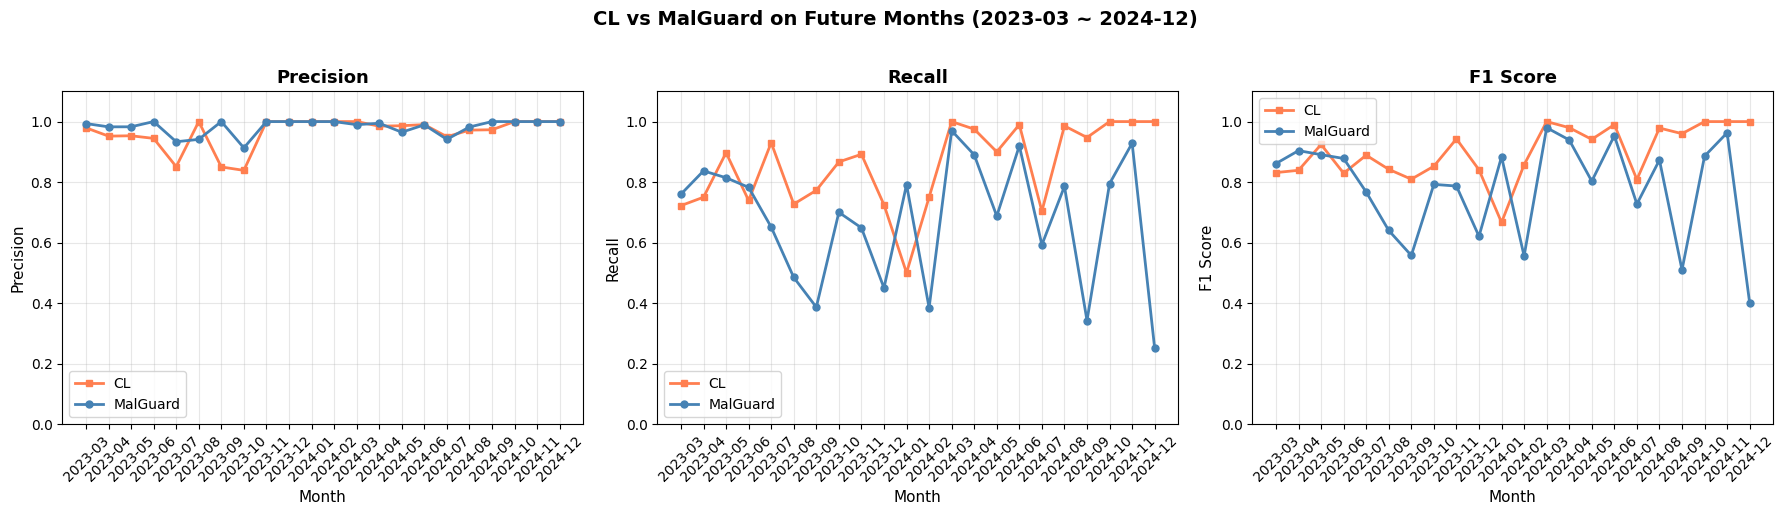

In [8]:
# 绘制3个子图：CL vs MalGuard
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 子图1: Precision
axes[0].plot(months, cl_precision, 's-', label='CL', color='coral', linewidth=2, markersize=5)
axes[0].plot(months, malguard_precision, 'o-', label='MalGuard', color='steelblue', linewidth=2, markersize=5)
axes[0].set_xlabel('Month', fontsize=11)
axes[0].set_ylabel('Precision', fontsize=11)
axes[0].set_title('Precision', fontsize=13, fontweight='bold')
axes[0].legend()
axes[0].set_ylim(0, 1.1)
axes[0].grid(alpha=0.3)
axes[0].tick_params(axis='x', rotation=45)

# 子图2: Recall
axes[1].plot(months, cl_recall, 's-', label='CL', color='coral', linewidth=2, markersize=5)
axes[1].plot(months, malguard_recall, 'o-', label='MalGuard', color='steelblue', linewidth=2, markersize=5)
axes[1].set_xlabel('Month', fontsize=11)
axes[1].set_ylabel('Recall', fontsize=11)
axes[1].set_title('Recall', fontsize=13, fontweight='bold')
axes[1].legend()
axes[1].set_ylim(0, 1.1)
axes[1].grid(alpha=0.3)
axes[1].tick_params(axis='x', rotation=45)

# 子图3: F1
axes[2].plot(months, cl_f1, 's-', label='CL', color='coral', linewidth=2, markersize=5)
axes[2].plot(months, malguard_f1, 'o-', label='MalGuard', color='steelblue', linewidth=2, markersize=5)
axes[2].set_xlabel('Month', fontsize=11)
axes[2].set_ylabel('F1 Score', fontsize=11)
axes[2].set_title('F1 Score', fontsize=13, fontweight='bold')
axes[2].legend()
axes[2].set_ylim(0, 1.1)
axes[2].grid(alpha=0.3)
axes[2].tick_params(axis='x', rotation=45)

plt.suptitle('CL vs MalGuard on Future Months (2023-03 ~ 2024-12)', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

In [9]:
# 统计对比: CL vs MalGuard
cl_f1_arr = np.array(cl_f1)
malguard_f1_arr = np.array(malguard_f1)

print("="*50)
print("CL vs MalGuard 统计对比")
print("="*50)
print(f"CL       - Mean Precision: {np.mean(cl_precision):.4f}, Mean Recall: {np.mean(cl_recall):.4f}, Mean F1: {np.mean(cl_f1_arr):.4f}")
print(f"MalGuard - Mean Precision: {np.mean(malguard_precision):.4f}, Mean Recall: {np.mean(malguard_recall):.4f}, Mean F1: {np.mean(malguard_f1_arr):.4f}")

improved = np.sum(cl_f1_arr > malguard_f1_arr)
degraded = np.sum(cl_f1_arr < malguard_f1_arr)
same = np.sum(cl_f1_arr == malguard_f1_arr)
print(f"CL相比MalGuard提升的月份数: {improved}, 下降: {degraded}, 相同: {same}")

CL vs MalGuard 统计对比
CL       - Mean Precision: 0.9648, Mean Recall: 0.8534, Mean F1: 0.8992
MalGuard - Mean Precision: 0.9822, Mean Recall: 0.6751, Mean F1: 0.7805
CL相比MalGuard提升的月份数: 18, 下降: 4, 相同: 0
